# Xử lý graph Ablation Study


## Thư viện cần thiết


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


## Truyền dữ liệu từ VI-Ablation Study


Lấy từng ticker ứng với từng folder và từng case trong kết quả ablation đã có.


In [2]:
# Tìm thư mục dữ liệu dù notebook được chạy từ JOURNAL_2026 hay từ thư mục gốc dự án.
def find_ablation_dir(start: Path) -> Path:
    start = start.resolve()
    relative_locations = (
        Path('VI-Ablation Study/kq_albation'),
        Path('application/JOURNAL_2026/VI-Ablation Study/kq_albation'),
    )
    for parent in (start, *start.parents):
        for relative in relative_locations:
            candidate = parent / relative
            if candidate.is_dir():
                return candidate
    raise FileNotFoundError('Không tìm thấy thư mục VI-Ablation Study/kq_albation.')


ABLATION_DIR = find_ablation_dir(Path.cwd())
CASES = (
    'without_vae',
    'without_cost_network',
    'without_confident_weighting',
)
CASE_LABELS = {
    'without_vae': 'Without VAE',
    'without_cost_network': 'Without Cost Network',
    'without_confident_weighting': 'Without Confidence Weighting',
}

# Mỗi thư mục cấp một là một ticker; chỉ nhận ticker có đủ summary của cả 3 case.
summary_files = {}
for ticker_dir in sorted(path for path in ABLATION_DIR.iterdir() if path.is_dir()):
    files = {
        case: ticker_dir / case / 'ablation_summary.csv'
        for case in CASES
    }
    if all(path.is_file() for path in files.values()):
        summary_files[ticker_dir.name] = files

if not summary_files:
    raise FileNotFoundError(
        f'Không tìm thấy ablation_summary.csv cho đủ 3 case trong {ABLATION_DIR}'
    )

frames = []
for ticker, files in summary_files.items():
    for case, csv_path in files.items():
        frame = pd.read_csv(csv_path)
        frame['_ticker'] = ticker
        frame['_case'] = case
        frames.append(frame)

ablation_results = pd.concat(frames, ignore_index=True)
TICKERS = tuple(summary_files)

expected_rows = len(TICKERS) * len(CASES)
if len(ablation_results) != expected_rows:
    raise ValueError(
        f'Kỳ vọng {expected_rows} dòng summary nhưng nhận được {len(ablation_results)}.'
    )

periods = sorted(ablation_results['period'].astype(str).str.upper().unique())
if periods != ['BAD']:
    raise ValueError(f'Dữ liệu ablation phải thuộc BAD period, nhận được: {periods}')

print(
    f'Đã nạp {len(frames)} file cho {len(TICKERS)} ticker '
    f'và {len(CASES)} case: {", ".join(TICKERS)}'
)


Đã nạp 18 file cho 6 ticker và 3 case: ACB, FPT, GAS, HPG, SSI, VCB


## Vẽ biểu đồ kết quả


Mục tiêu hình vẽ: Vẽ biểu đồ cột cho mỗi độ đo của bài ablation study, lấy từ các ticker ở mỗi case. Chỉ lấy 6 độ đo chính giống notebook kết quả chính: Profit, ROI %, ARR %, Sharpe Ratio, Max Drawdown và Violation. Đơn vị được trình bày đầy đủ: Profit (%), ROI (%), ARR (%), Sharpe Ratio, Max Drawdown (%) và Violation (count). Không cần tựa đề trong biểu đồ. Dữ liệu ablation hiện có BAD period; mỗi case được phân bằng một cell Markdown và có một hình riêng. Trong mỗi độ đo, 6 cột tương ứng với 6 ticker và dùng màu nhất quán giữa các case. Không tạo thêm file, chỉ hiển thị hình trong output notebook.


In [3]:
# Cột dữ liệu và nhãn đầy đủ, giữ đúng rule của notebook kết quả chính.
METRICS = (
    ('test_profit_mean', 'Profit (%)'),
    ('test_roi_mean', 'ROI (%)'),
    ('test_arr_mean', 'ARR (%)'),
    ('test_sharpe_mean', 'Sharpe Ratio'),
    ('test_max_drawdown_mean', 'Max Drawdown (%)'),
    ('test_violations_mean', 'Violation (count)'),
)
TICKER_COLORS = {
    ticker: color for ticker, color in zip(
        TICKERS,
        ('#2878B5', '#F28E2B', '#59A14F', '#E15759', '#B07AA1', '#76B7B2'),
    )
}

required_columns = {'_ticker', '_case', 'period'} | {column for column, _ in METRICS}
missing_columns = required_columns - set(ablation_results.columns)
if missing_columns:
    raise KeyError(f'Thiếu các cột bắt buộc: {sorted(missing_columns)}')


def annotate_bar(ax, bar, value):
    """Ghi giá trị trung bình lên từng cột."""
    if not np.isfinite(value):
        return
    offset = 4 if value >= 0 else -4
    ax.annotate(
        f'{value:,.2f}',
        (bar.get_x() + bar.get_width() / 2, value),
        xytext=(0, offset),
        textcoords='offset points',
        ha='center',
        va='bottom' if value >= 0 else 'top',
        fontsize=8.5,
        clip_on=False,
    )


def plot_ablation_case(case):
    """Một case tạo một hình 2 x 3, mỗi panel chứa đủ 6 ticker."""
    case_data = (
        ablation_results.loc[ablation_results['_case'].eq(case)]
        .drop_duplicates('_ticker', keep='last')
        .set_index('_ticker')
        .reindex(TICKERS)
    )
    metric_columns = [column for column, _ in METRICS]
    if case_data[metric_columns].isna().all(axis=None):
        raise ValueError(f'Case {case} không có dữ liệu metric hợp lệ.')

    fig, axes = plt.subplots(2, 3, figsize=(16, 8.5), constrained_layout=True)
    x = np.arange(len(TICKERS), dtype=float)

    for ax, (column, label) in zip(axes.flat, METRICS):
        values = pd.to_numeric(case_data[column], errors='coerce').to_numpy(dtype=float)
        bars = ax.bar(
            x,
            values,
            width=0.68,
            color=[TICKER_COLORS[ticker] for ticker in TICKERS],
            edgecolor='white',
            linewidth=0.8,
            zorder=3,
        )
        for bar, value in zip(bars, values):
            annotate_bar(ax, bar, value)

        ax.set_ylabel(label)
        ax.set_xticks(x, TICKERS)
        ax.axhline(0, color='#555555', linewidth=0.8, zorder=2)
        ax.grid(axis='y', linestyle='--', alpha=0.25, zorder=0)
        ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.2f}'))
        ax.margins(y=0.24)

    # Không đặt title/suptitle; tên case nằm ở cell Markdown ngay phía trên.
    plt.show()
    plt.close(fig)


### Case 1 — Without VAE (`without_vae`)

Kết quả BAD period khi loại bỏ thành phần VAE trên toàn bộ 6 ticker.


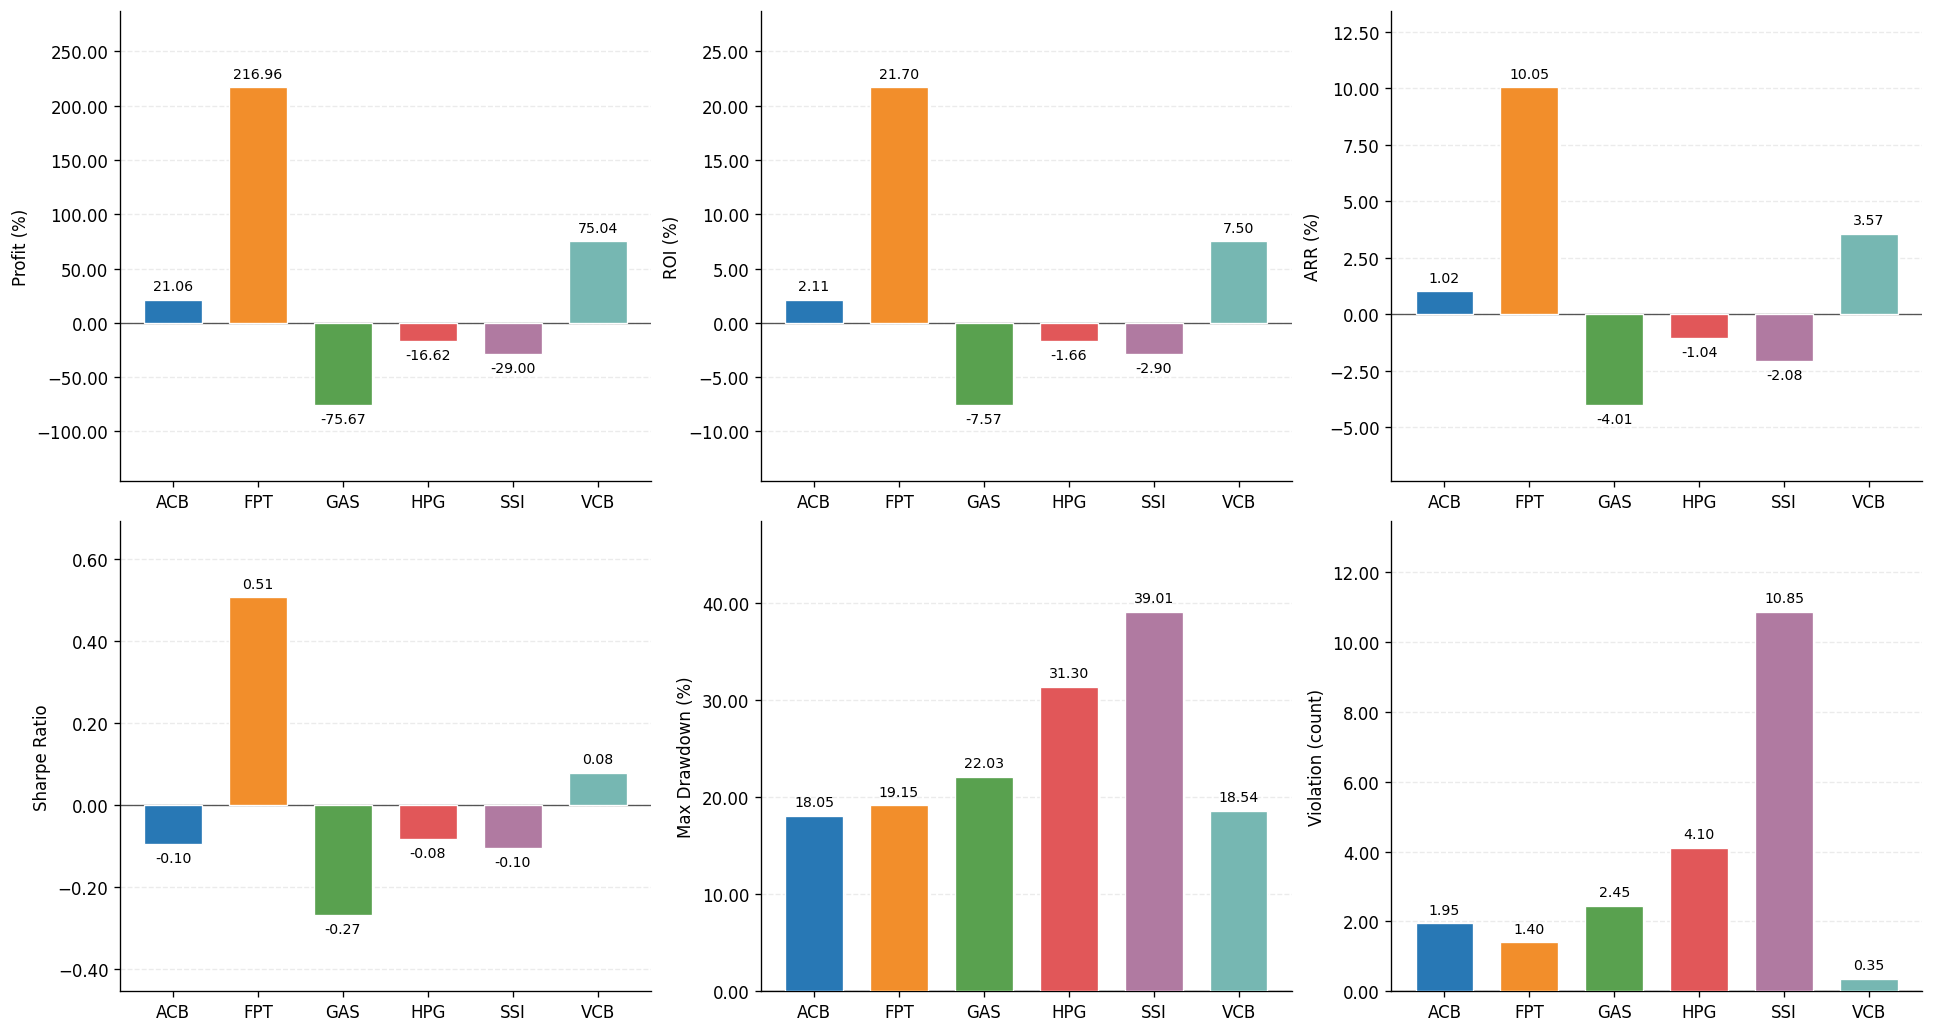

In [4]:
plot_ablation_case('without_vae')


### Case 2 — Without Cost Network (`without_cost_network`)

Kết quả BAD period khi loại bỏ Cost Network trên toàn bộ 6 ticker.


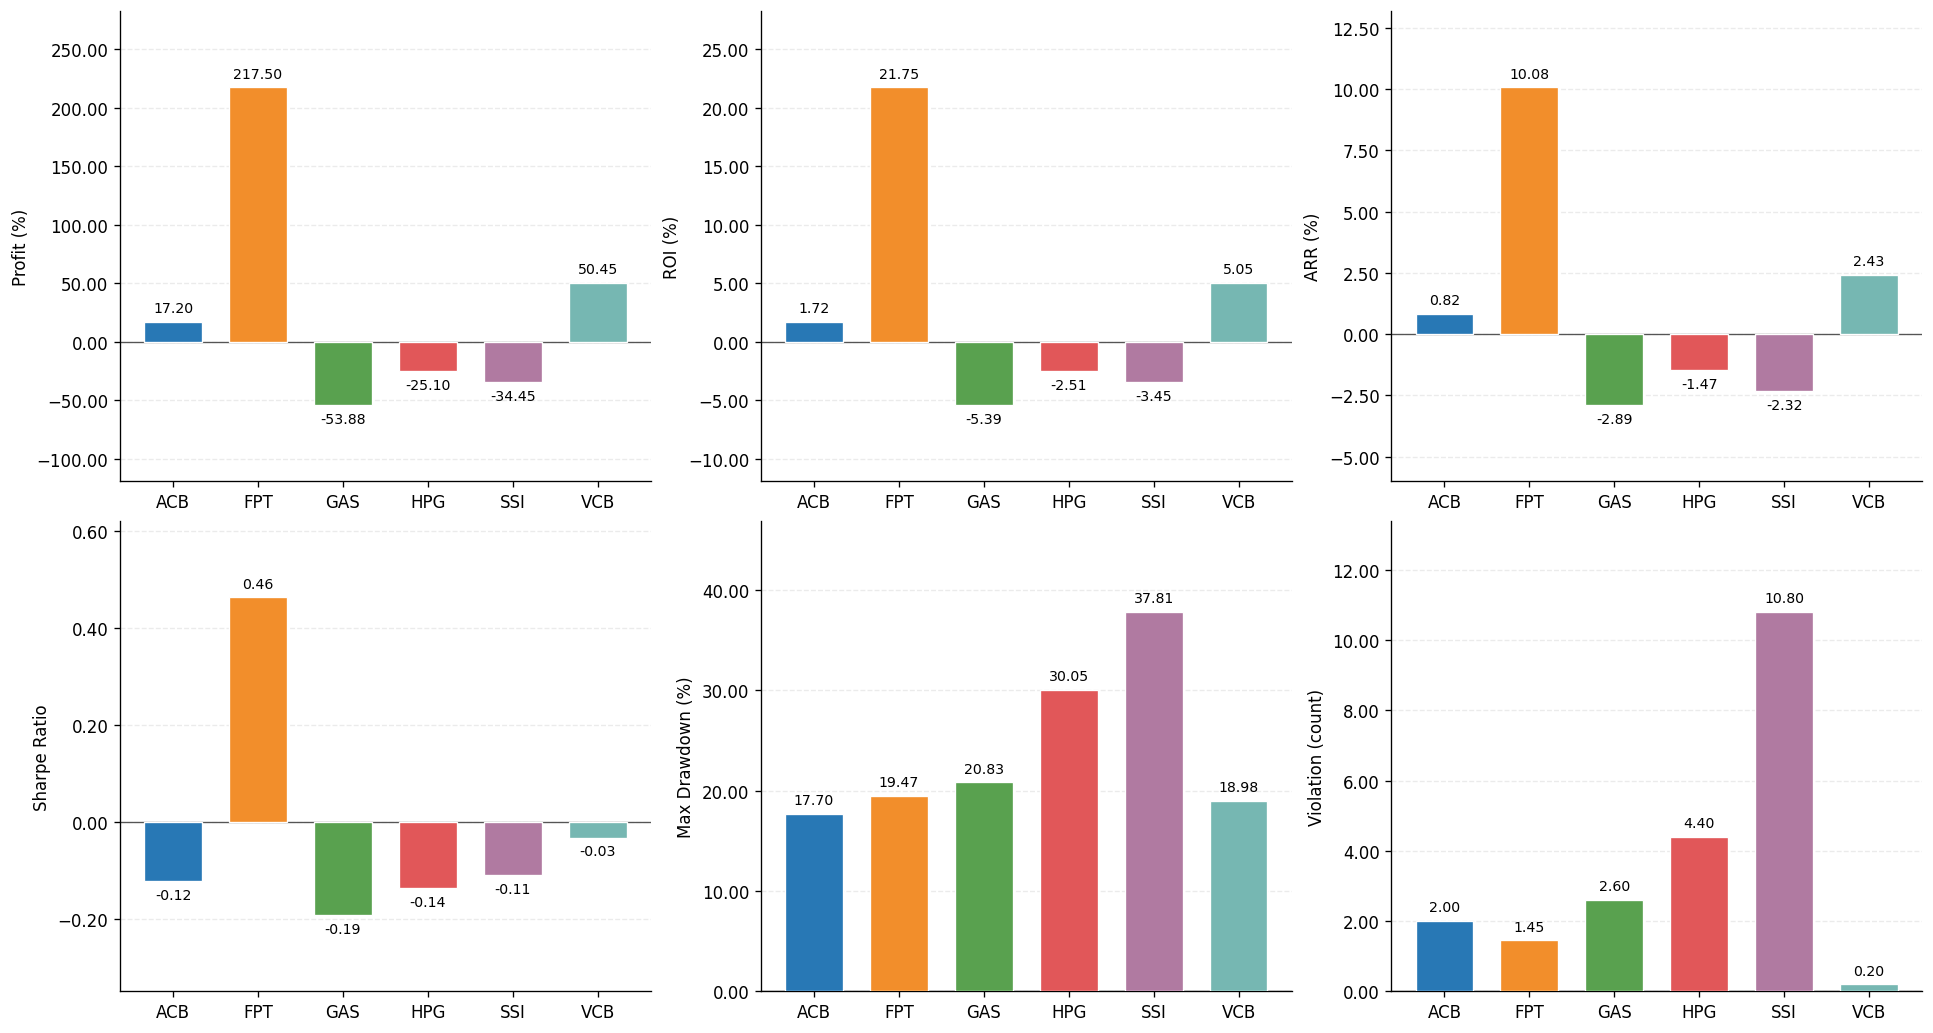

In [5]:
plot_ablation_case('without_cost_network')


### Case 3 — Without Confidence Weighting (`without_confident_weighting`)

Kết quả BAD period khi loại bỏ Confidence Weighting trên toàn bộ 6 ticker.


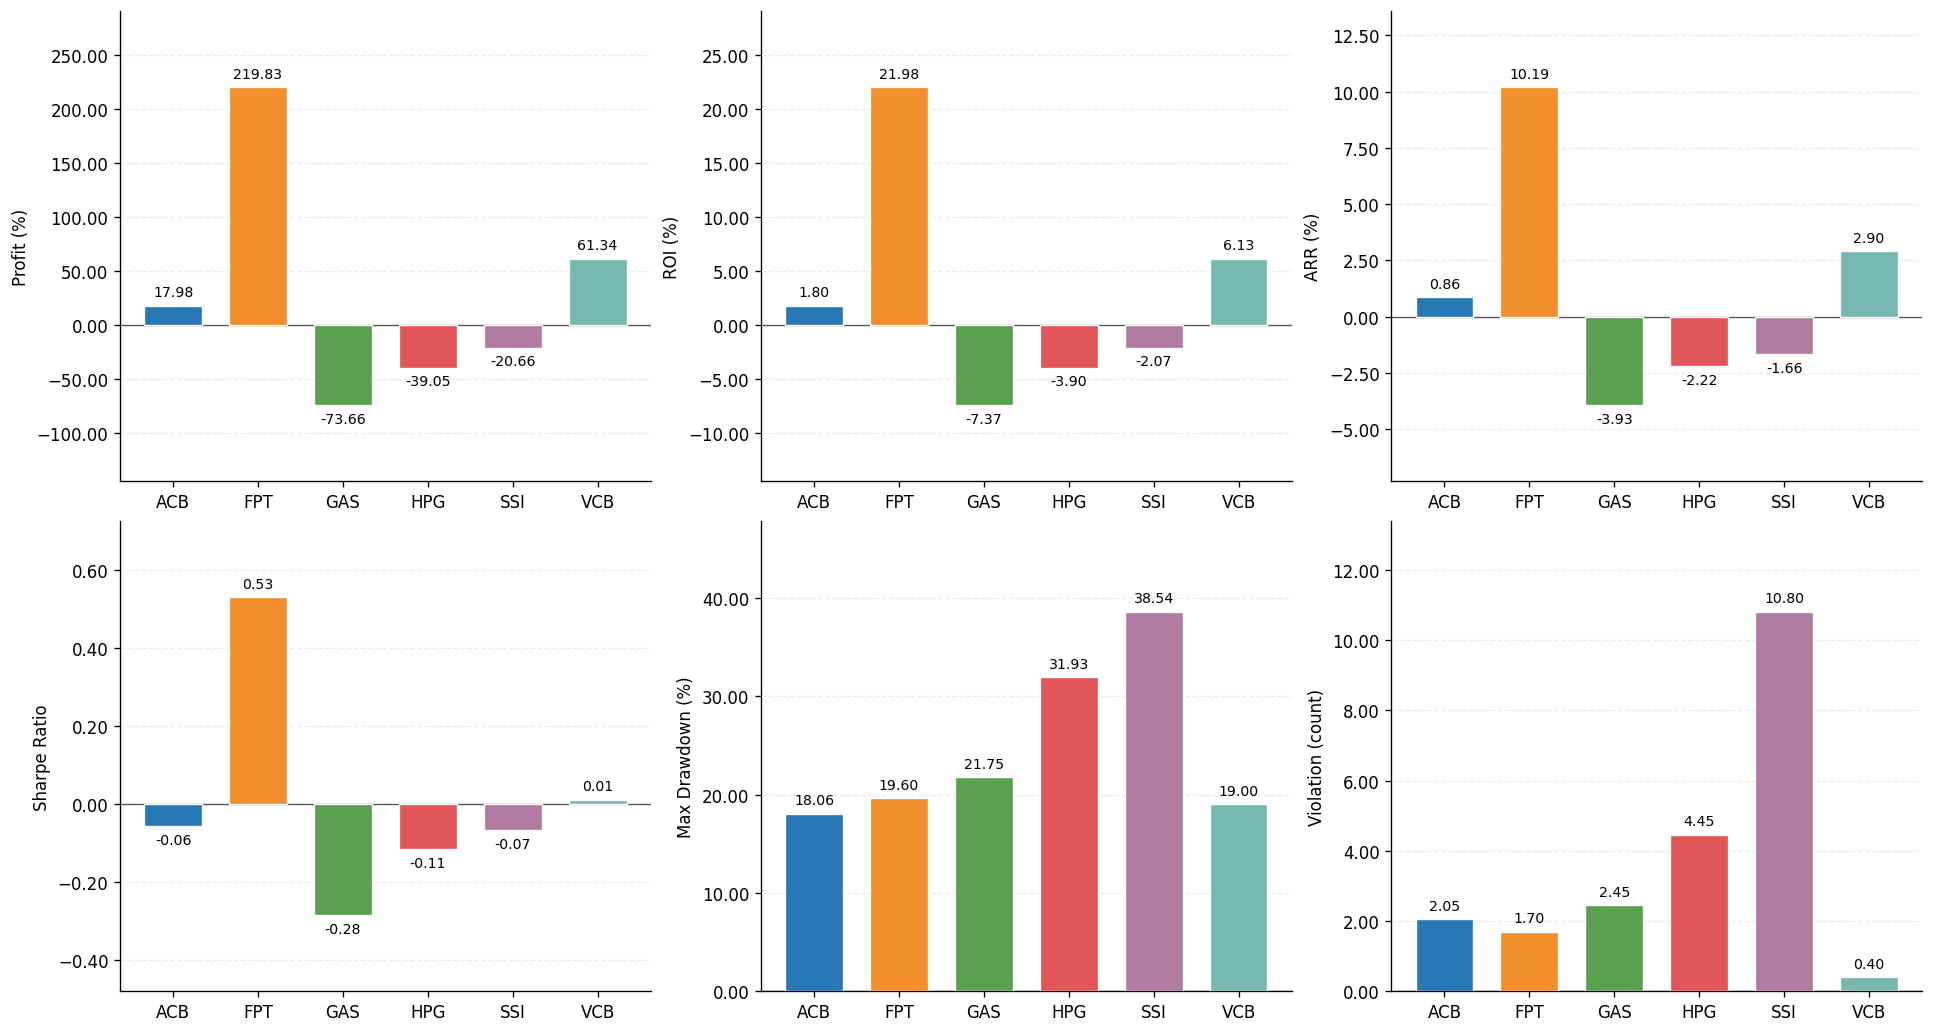

In [6]:
plot_ablation_case('without_confident_weighting')
